# MOF-5 ASE MD analysis

This notebook analyzes trajectories written by `python run.py`. It plots energy, temperature, and maximum force over time, then opens the trajectory in an interactive Chemiscope 3D viewer.

Run a short simulation first. The default files are written under `output/`.

In [1]:
from pathlib import Path

import ase.io
import chemiscope
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'output').is_dir():
    PROJECT_DIR = Path.cwd() / 'work' / 'mof-heat-capacity'

OUTPUT_DIR = PROJECT_DIR / 'output'
trajectory_paths = sorted(OUTPUT_DIR.rglob('*.traj'), key=lambda path: path.stat().st_mtime)
if not trajectory_paths:
    raise FileNotFoundError('No ASE trajectory found below output/. Run `python run.py --rerun` first.')

TRAJECTORY_PATH = trajectory_paths[-1]
LOG_PATH = TRAJECTORY_PATH.with_suffix('.log')
print(f'Analyzing trajectory: {TRAJECTORY_PATH}')
print(f'Using MD log: {LOG_PATH}')

Analyzing trajectory: /home/dealmeid/project/work/mof-heat-capacity/output/long-run/mof5-ase-100.traj
Using MD log: /home/dealmeid/project/work/mof-heat-capacity/output/long-run/mof5-ase-100.log


In [2]:
frames = ase.io.read(TRAJECTORY_PATH, index=':')
if not frames:
    raise ValueError(f'No frames were found in {TRAJECTORY_PATH}')

print(f'Frames: {len(frames)}')
print(f'Atoms per frame: {len(frames[0])}')
print(f'Cell volume: {frames[0].cell.volume:.3f} A^3')
print(f'Elements: {sorted(set(frames[0].get_chemical_symbols()))}')

Frames: 101
Atoms per frame: 424
Cell volume: 17305.325 A^3
Elements: ['C', 'H', 'O', 'Zn']


In [3]:
if not LOG_PATH.is_file():
    raise FileNotFoundError(f'MD log not found: {LOG_PATH}')

md_data = np.loadtxt(LOG_PATH, skiprows=1)
md_data = np.atleast_2d(md_data)
time_ps, total_energy_ev, potential_energy_ev, kinetic_energy_ev, temperature_k = md_data.T

print(f'Logged MD records: {len(time_ps)}')
print(f'Potential-energy range: {potential_energy_ev.min():.6f} to {potential_energy_ev.max():.6f} eV')
print(f'Temperature range: {temperature_k.min():.2f} to {temperature_k.max():.2f} K')

Logged MD records: 101
Potential-energy range: -3089.525000 to -3080.751000 eV
Temperature range: 151.60 to 303.20 K


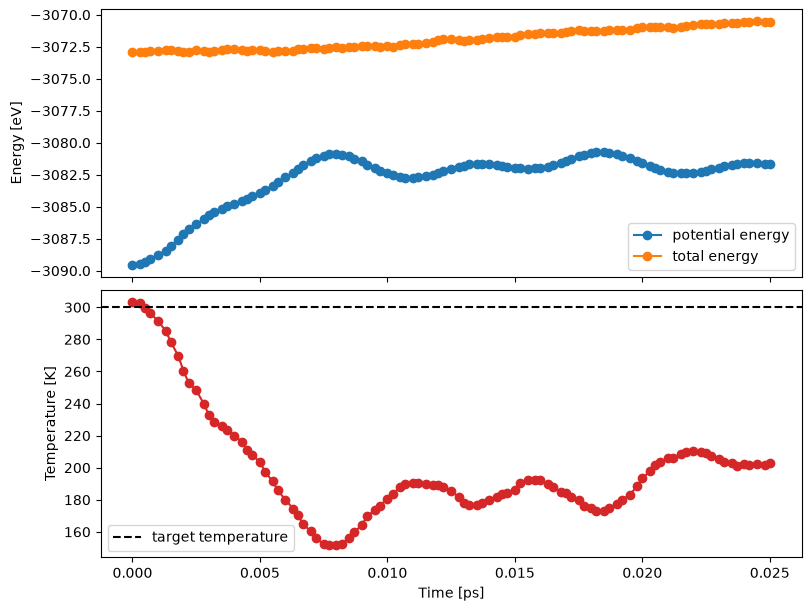

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, layout='constrained')

axes[0].plot(time_ps, potential_energy_ev, marker='o', label='potential energy')
axes[0].plot(time_ps, total_energy_ev, marker='o', label='total energy')
axes[0].set_ylabel('Energy [eV]')
axes[0].legend()

axes[1].plot(time_ps, temperature_k, marker='o', color='tab:red')
axes[1].axhline(300.0, color='black', linestyle='--', label='target temperature')
axes[1].set_xlabel('Time [ps]')
axes[1].set_ylabel('Temperature [K]')
axes[1].legend()

plt.show()

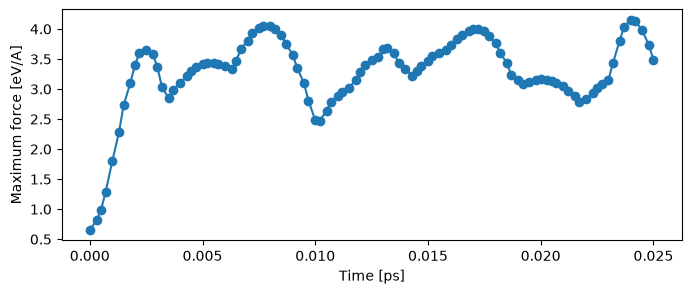

In [5]:
max_force_ev_per_a = []
force_frames = []

for frame in frames:
    try:
        forces = frame.get_forces()
    except Exception:
        max_force_ev_per_a = []
        force_frames = []
        break

    force_frames.append(forces)
    max_force_ev_per_a.append(np.linalg.norm(forces, axis=1).max())

if max_force_ev_per_a:
    frame_time_ps = time_ps[:len(max_force_ev_per_a)]
    plt.figure(figsize=(8, 3))
    plt.plot(frame_time_ps, max_force_ev_per_a, marker='o')
    plt.xlabel('Time [ps]')
    plt.ylabel('Maximum force [eV/A]')
    plt.show()
else:
    print('Forces are not stored in this trajectory; rerun the ASE workflow to include them.')

## Interactive 3D trajectory

Use the timeline in Chemiscope's structure viewer to inspect every stored frame. Energy and temperature are included as per-frame properties; force arrows are included when forces are stored in the trajectory.

In [6]:
frame_count = min(len(frames), len(time_ps))
viewer_frames = frames[:frame_count]

properties = {
    'frame': np.arange(frame_count),
    'time': {
        'target': 'structure',
        'values': time_ps[:frame_count],
        'units': 'ps',
        'description': 'ASE MD time',
    },
    'potential energy': {
        'target': 'structure',
        'values': potential_energy_ev[:frame_count],
        'units': 'eV',
    },
    'temperature': {
        'target': 'structure',
        'values': temperature_k[:frame_count],
        'units': 'K',
    },
}

shapes = {}
if len(force_frames) >= frame_count:
    for frame, forces in zip(viewer_frames, force_frames[:frame_count], strict=True):
        frame.arrays['forces_eV_per_A'] = forces

    shapes['forces'] = chemiscope.ase_vectors_to_arrows(
        viewer_frames, 'forces_eV_per_A', scale=1.0, radius=0.08
    )

viewer_settings = {
    'structure': [{'keepOrientation': True, 'playbackDelay': 150}],
    'map': {'joinPoints': True},
}
if 'forces' in shapes:
    viewer_settings['structure'][0]['shape'] = 'forces'

viewer = chemiscope.show(
    structures=viewer_frames,
    properties=properties,
    shapes=shapes,
    settings=viewer_settings,
    mode='default',
)
display(viewer)

<ChemiscopeWidget(meta={'name': ' '}, settings={'structure': [{'keepOrientation': True, 'playbackDelay': 150, '...}, structures=[{'size': 424, 'data': 'structure-0'}, {'size': 424, 'data': 'st...}, shapes={'forces': {'kind': 'arrow', 'parameters': {'global': {'baseRadi...}, properties={'frame': {'target': 'structure', 'values': [0.0, 1.0, 2.0, 3.0,...}, )>

In [7]:
chemiscope_path = str(OUTPUT_DIR / f"{TRAJECTORY_PATH.stem}.json.gz")
viewer.save(chemiscope_path)
print(f'Saved Chemiscope dataset: {chemiscope_path}')
print('Open this .json.gz file at https://chemiscope.org to inspect it outside Jupyter.')

Saved Chemiscope dataset: /home/dealmeid/project/work/mof-heat-capacity/output/mof5-ase-100.json.gz
Open this .json.gz file at https://chemiscope.org to inspect it outside Jupyter.
